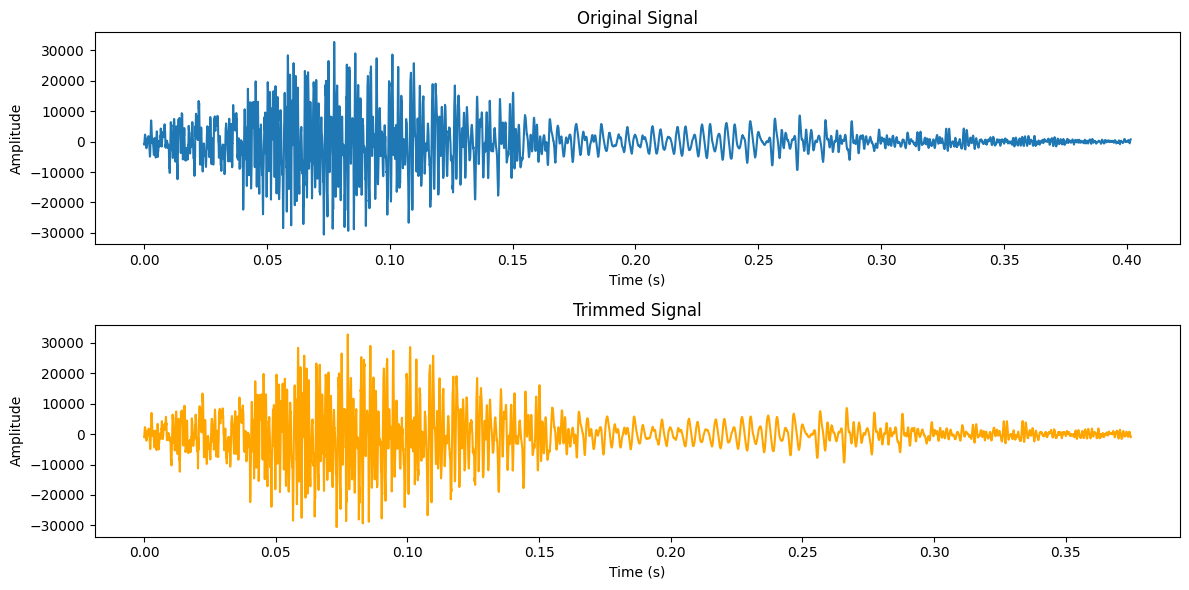

In [4]:
import wave
import numpy as np
import matplotlib.pyplot as plt
plt.close('all')

# Load the WAV file
file_path =r"D:\Upiita\6to\Patrones\Objetos\palabras\agua_1.wav"
with wave.open(file_path, 'rb') as wav_file:
    params = wav_file.getparams()
    n_channels, samp_width, frame_rate, n_frames, comp_type, comp_name = params[:6]
    frames = wav_file.readframes(n_frames)
 
# Convert byte data to numpy array
data = np.frombuffer(frames, dtype=np.int16)
duration = n_frames / frame_rate
 
# Normalize the signal and compute its envelope
data_norm = data / np.max(np.abs(data))
threshold = 0.03  # Amplitude threshold
 
# Find active regions
active_idx = np.where(np.abs(data_norm) > threshold)[0]
start_idx = active_idx[0]
end_idx = active_idx[-1]
 
# Trim the signal
data_trimmed = data[start_idx:end_idx+1]
 
# Plot original and trimmed signals
time = np.linspace(0, duration, len(data))
time_trimmed = np.linspace(start_idx / frame_rate, end_idx / frame_rate, len(data_trimmed))
 
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, data, label="Original Signal")
plt.title("Original Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
 
plt.subplot(2, 1, 2)
plt.plot(time_trimmed, data_trimmed, label="Trimmed Signal", color='orange')
plt.title("Trimmed Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
 
plt.tight_layout()
plt.show()

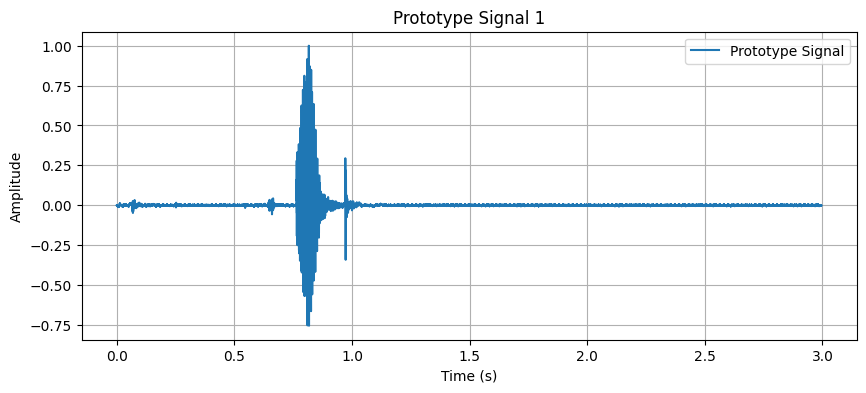

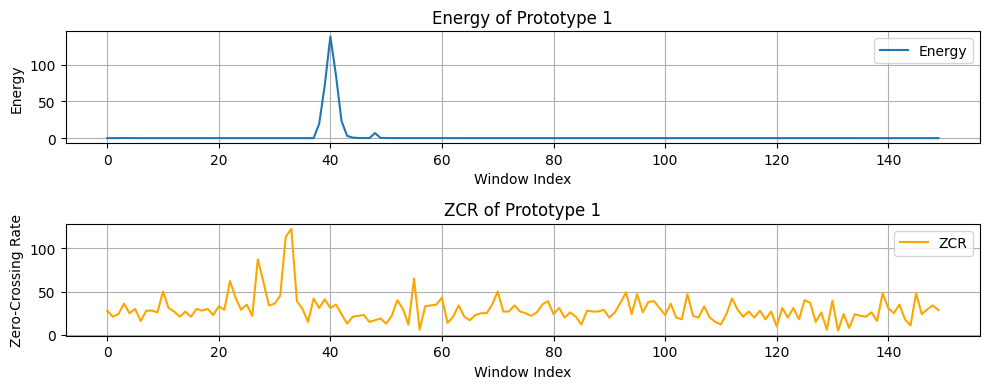

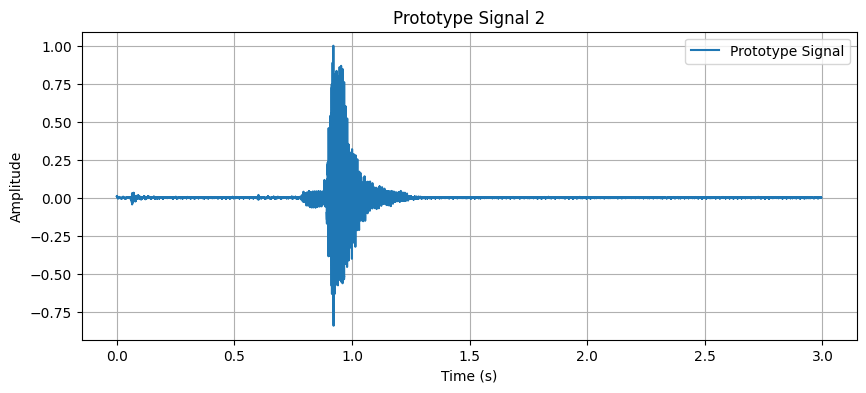

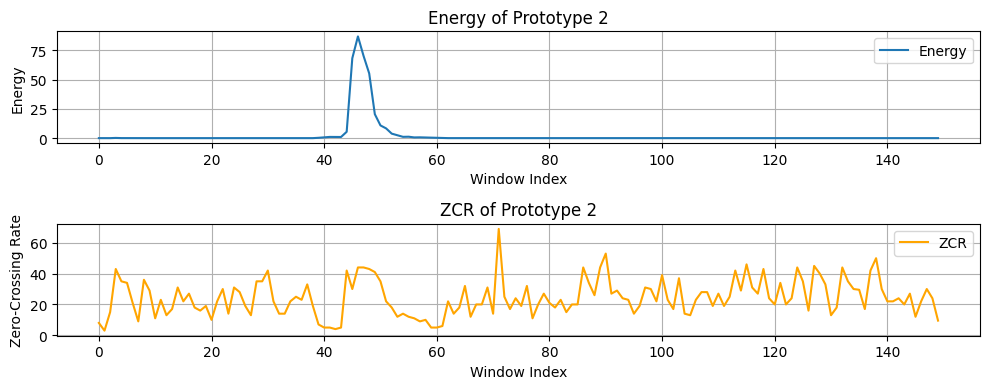

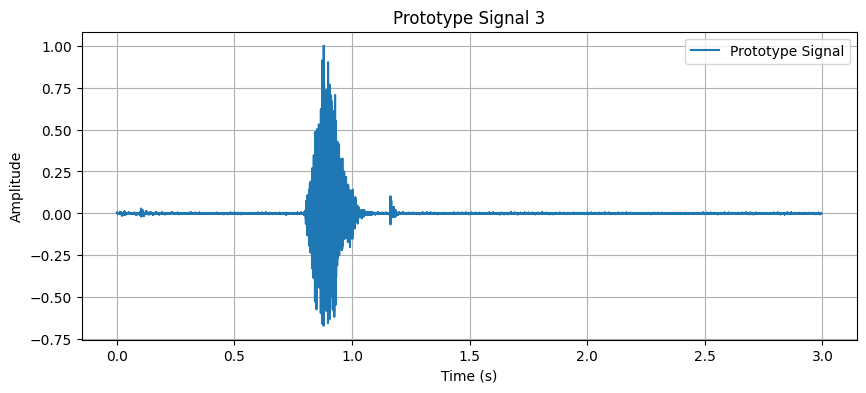

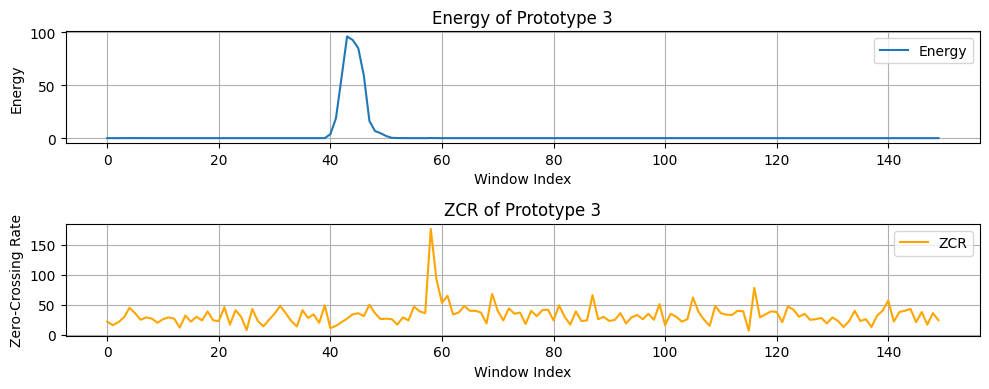

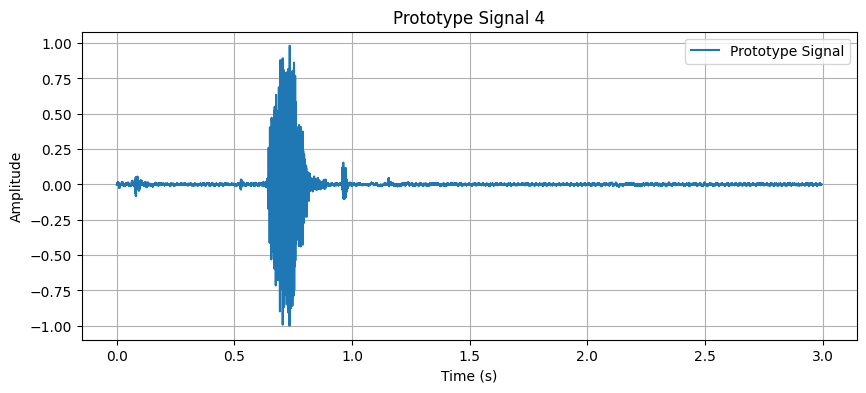

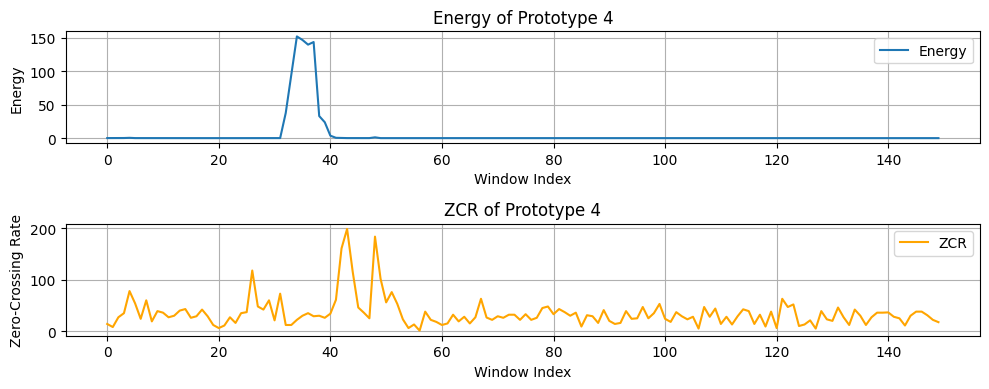

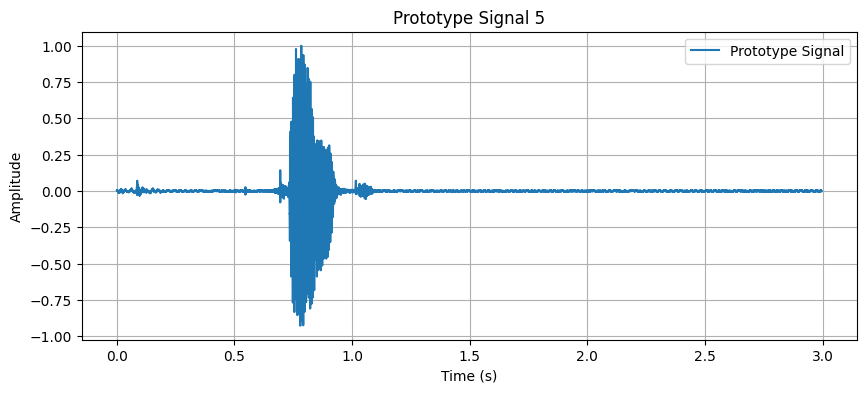

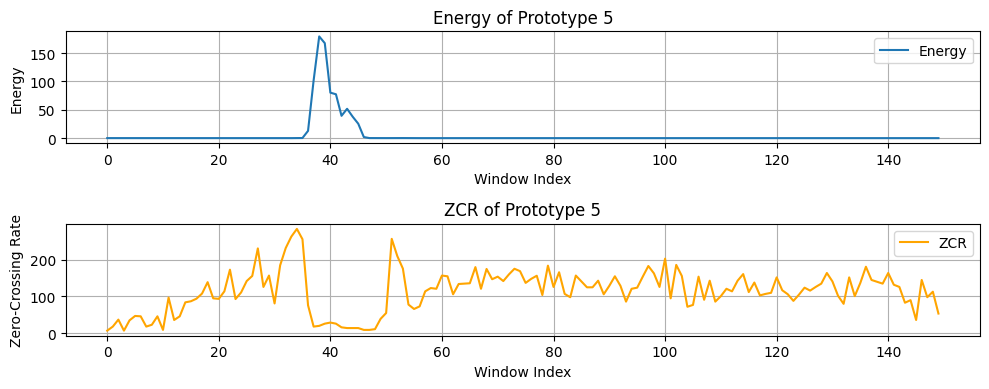

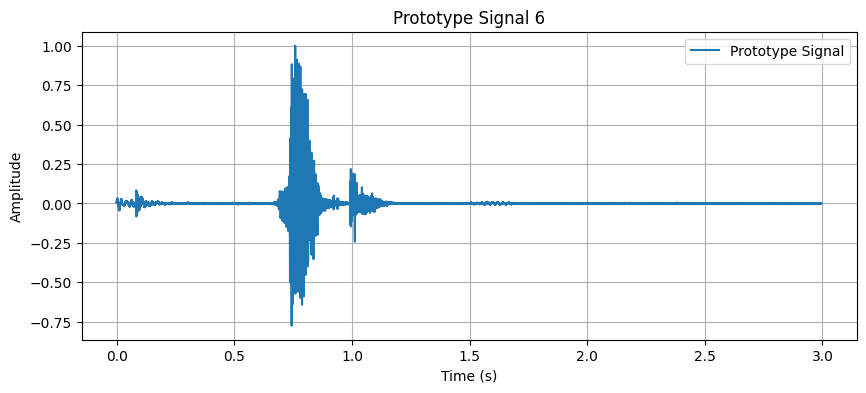

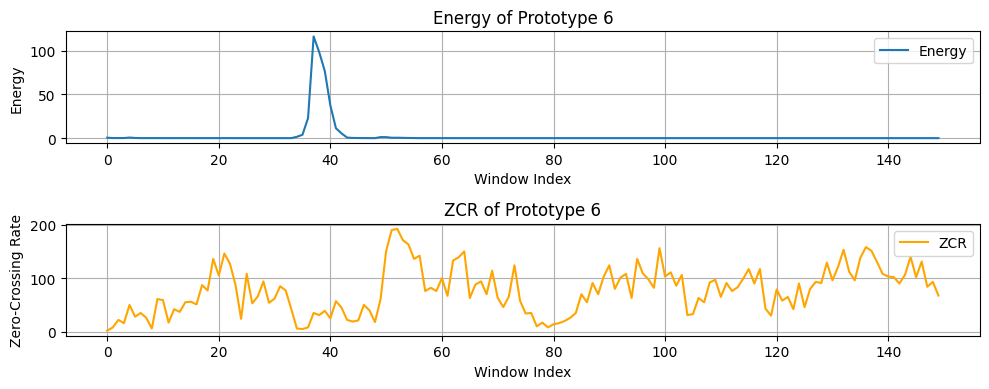

In [5]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
 
# Prototype audio file paths
# proto_files = [
#     r"D:\Upiita\6to\Patrones\Objetos\palabras\agua_1.wav",
#     r"D:\Upiita\6to\Patrones\Objetos\palabras\cafe_1.wav", 
#     r"D:\Upiita\6to\Patrones\Objetos\palabras\jugo_1.wav"]
proto_files = [
    r"D:\Upiita\6to\Patrones\Proyectos\Carrito\up.wav",
    r"D:\Upiita\6to\Patrones\Proyectos\Carrito\down.wav", 
    r"D:\Upiita\6to\Patrones\Proyectos\Carrito\right.wav",
    r"D:\Upiita\6to\Patrones\Proyectos\Carrito\left.wav",
    r"D:\Upiita\6to\Patrones\Proyectos\Carrito\front.wav",
    r"D:\Upiita\6to\Patrones\Proyectos\Carrito\back.wav"]
# Store prototype features
proto_feats = []
 
# Window parameters
win_dur = 0.02  # 20 ms
 
# Process prototypes
for idx, file in enumerate(proto_files):
    # Read audio
    Fs, sig = wav.read(file)
    # Normalize
    sig = sig / np.max(np.abs(sig))
    # Convert to mono if stereo
    if len(sig.shape) > 1:
        sig = sig[:, 0]
    # Window length and step
    win_len = int(win_dur * Fs)
    step = win_len
    # Number of windows
    n_windows = int(np.ceil((len(sig) - win_len) / step)) + 1
    # Pad signal
    pad_len = n_windows * step + win_len
    sig_pad = np.append(sig, np.zeros(pad_len - len(sig)))
    # Energy and ZCR
    eng = []
    zcr = []
    for i in range(n_windows):
        start = i * step
        end = start + win_len
        win = sig_pad[start:end]
        eng.append(np.sum(win ** 2))
        zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)
    # Store features
    feats = np.column_stack((eng, zcr))
    proto_feats.append(feats)
 
    # Visualize prototype signal
    time = np.linspace(0, len(sig) / Fs, len(sig))
    plt.figure(figsize=(10, 4))
    plt.plot(time, sig, label="Prototype Signal")
    plt.title(f"Prototype Signal {idx+1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()
 
    # Visualize energy and ZCR
    plt.figure(figsize=(10, 4))
    plt.subplot(2, 1, 1)
    plt.plot(eng, label="Energy")
    plt.title(f"Energy of Prototype {idx+1}")
    plt.xlabel("Window Index")
    plt.ylabel("Energy")
    plt.grid()
    plt.legend()
 
    plt.subplot(2, 1, 2)
    plt.plot(zcr, label="ZCR", color="orange")
    plt.title(f"ZCR of Prototype {idx+1}")
    plt.xlabel("Window Index")
    plt.ylabel("Zero-Crossing Rate")
    plt.grid()
    plt.legend()
 
    plt.tight_layout()
    plt.show()

[[3.87083802e-02 2.10000000e+01]
 [7.94482200e-03 3.65000000e+01]
 [7.62131108e-03 2.90000000e+01]
 [1.65547619e-01 2.30000000e+01]
 [2.55219550e-01 3.60000000e+01]
 [9.06955392e-02 3.40000000e+01]
 [1.83585800e-02 2.90000000e+01]
 [2.49197810e-02 2.20000000e+01]
 [1.06522106e-02 1.50000000e+01]
 [1.48350049e-02 1.90000000e+01]
 [7.86897791e-03 3.30000000e+01]
 [1.93282335e-02 1.00000000e+01]
 [1.35219397e-02 1.80000000e+01]
 [8.83174854e-03 1.50000000e+01]
 [1.02906287e-02 1.30000000e+01]
 [7.99149063e-03 4.90000000e+01]
 [9.73703164e-03 4.00000000e+01]
 [6.45777230e-03 3.70000000e+01]
 [6.16890591e-03 2.70000000e+01]
 [7.99702581e-03 2.20000000e+01]
 [1.11972632e-02 1.80000000e+01]
 [8.99521867e-03 1.80000000e+01]
 [1.13515760e-02 1.30000000e+01]
 [7.87230107e-03 3.10000000e+01]
 [5.67092155e-03 5.30000000e+01]
 [9.34689450e-03 3.50000000e+01]
 [6.36524162e-03 1.80000000e+01]
 [8.52534893e-03 2.50000000e+01]
 [9.38456787e-03 1.40000000e+01]
 [9.09627799e-03 1.90000000e+01]
 [7.791407

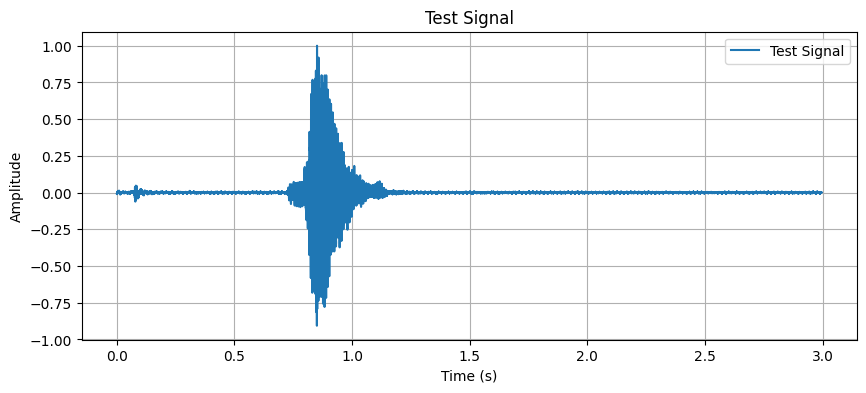

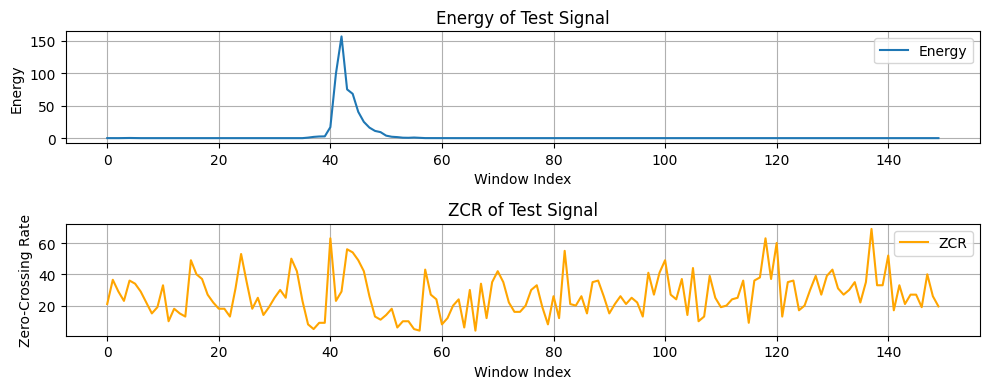

In [7]:
# Test pattern
# test_file = r"D:\Upiita\6to\Patrones\Objetos\palabras\agua_2.wav"
# test_file = r"D:\Upiita\6to\Patrones\Objetos\palabras\cafe_2.wav"
# test_file = r"D:\Upiita\6to\Patrones\Objetos\palabras\jugo_2.wav"
# test_file = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\up1.wav"
test_file = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\down1.wav" 
# test_file = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\right1.wav"
# test_file = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\left1.wav"
# test_file = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\front1.wav"
# test_file = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\back1.wav"
Fs, test_sig = wav.read(test_file)
test_sig = test_sig / np.max(np.abs(test_sig))
if len(test_sig.shape) > 1:
    test_sig = test_sig[:, 0]
# Window length and step
win_len = int(win_dur * Fs)
step = win_len
# Number of windows
n_windows = int(np.ceil((len(test_sig) - win_len) / step)) + 1
# Pad signal
pad_len = n_windows * step + win_len
test_sig_pad = np.append(test_sig, np.zeros(pad_len - len(test_sig)))
# Energy and ZCR
test_eng = []
test_zcr = []
for i in range(n_windows):
    start = i * step
    end = start + win_len
    win = test_sig_pad[start:end]
    test_eng.append(np.sum(win ** 2))
    test_zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)
# Store test features
test_feats = np.column_stack((test_eng, test_zcr))
print(test_feats)
print(test_eng)
print(test_zcr)

 
# Visualize test signal
time = np.linspace(0, len(test_sig) / Fs, len(test_sig))
plt.figure(figsize=(10, 4))
plt.plot(time, test_sig, label="Test Signal")
plt.title("Test Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()
 
# Visualize energy and ZCR of test signal
plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(test_eng, label="Energy")
plt.title("Energy of Test Signal")
plt.xlabel("Window Index")
plt.ylabel("Energy")
plt.grid()
plt.legend()
 
plt.subplot(2, 1, 2)
plt.plot(test_zcr, label="ZCR", color="orange")
plt.title("ZCR of Test Signal")
plt.xlabel("Window Index")
plt.ylabel("Zero-Crossing Rate")
plt.grid()
plt.legend()
 
plt.tight_layout()
plt.show()

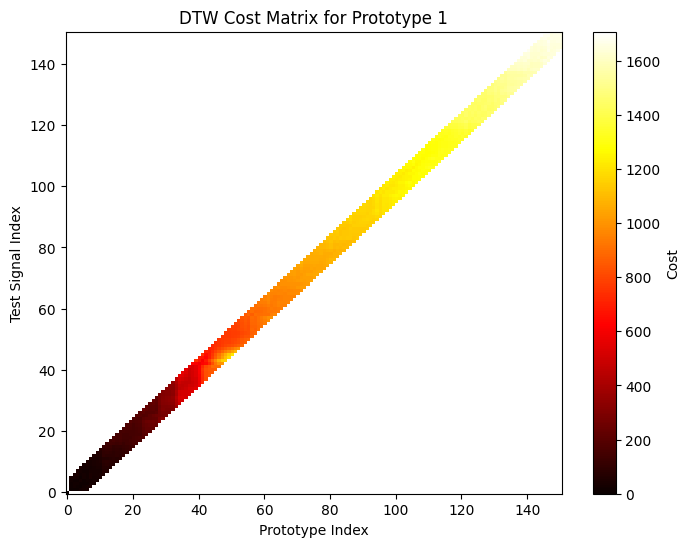

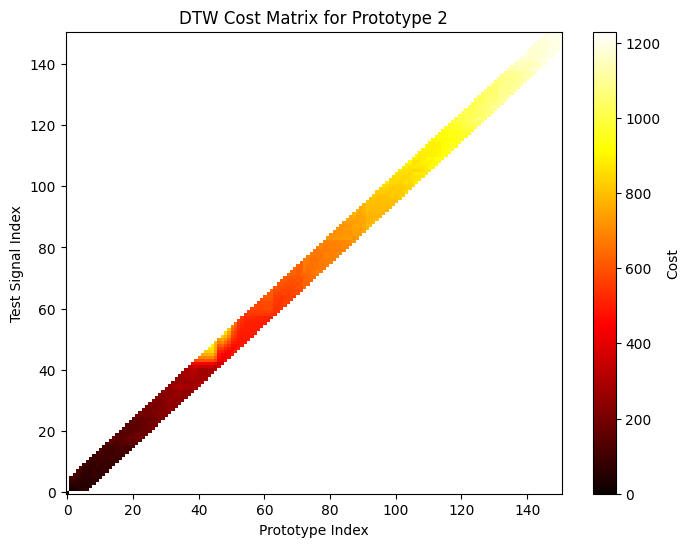

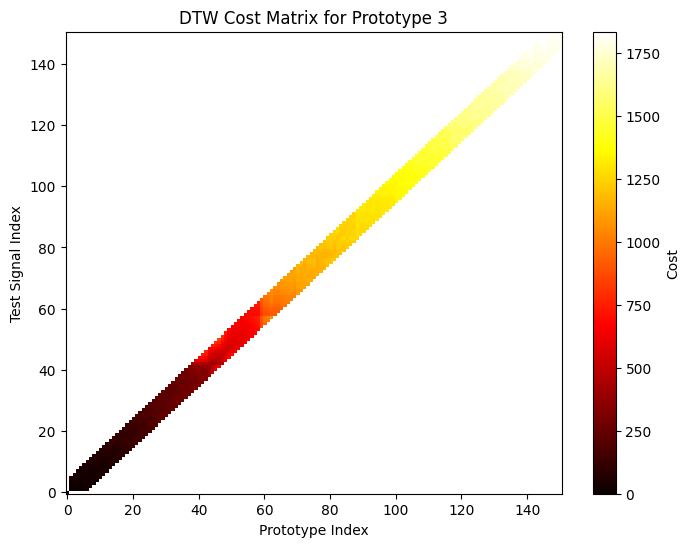

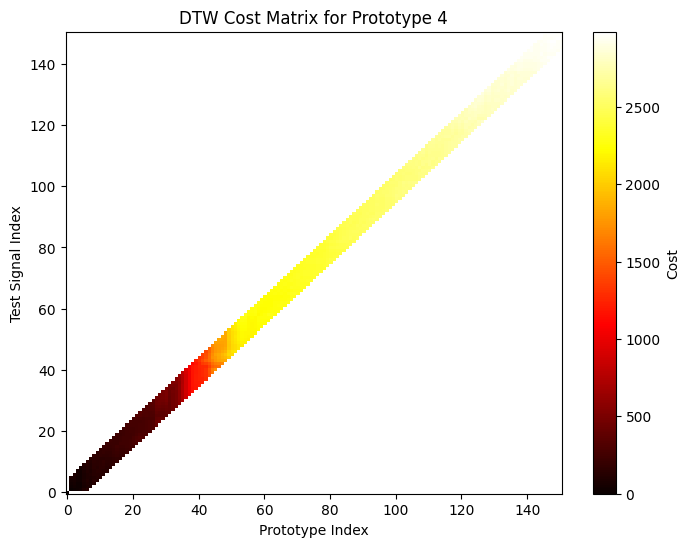

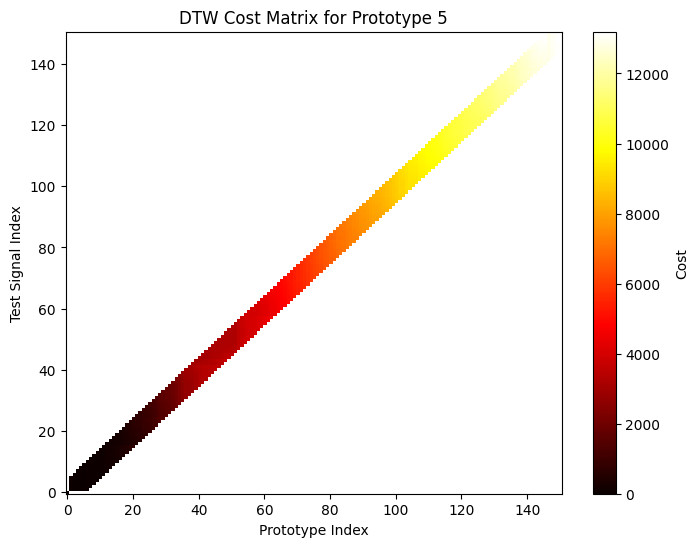

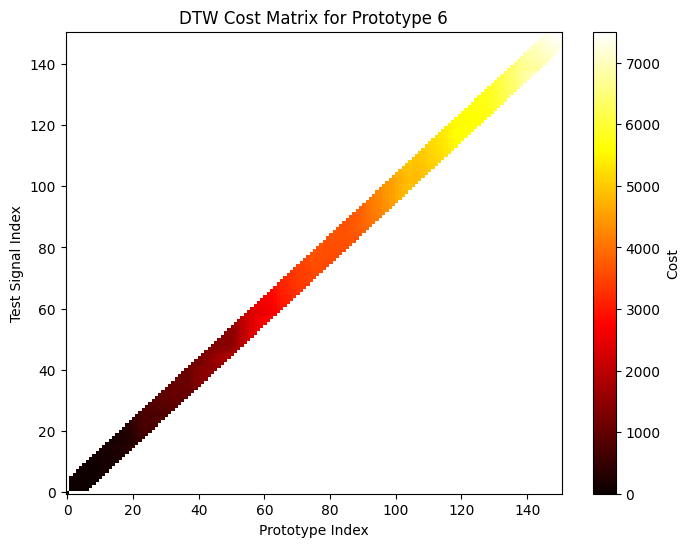

The unknown pattern has been identified as: D:\Upiita\6to\Patrones\Proyectos\Carrito\down


In [27]:
# DTW Recognition
tol_sec = 0.1  # Tolerance in seconds
tol_win = int(tol_sec / win_dur)
costs = []
 
for idx, proto in enumerate(proto_feats):
    n, m = len(proto), len(test_feats)
    win = max(tol_win, abs(n - m))
    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0
    for j in range(1, n + 1):
        for k in range(max(1, j - win), min(m + 1, j + win)):
            cost = np.linalg.norm(proto[j - 1] - test_feats[k - 1])
            dtw[j, k] = cost + min(dtw[j - 1, k], dtw[j, k - 1], dtw[j - 1, k - 1])
    costs.append(dtw[n, m])
 
    # Visualize DTW cost matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(dtw.T, origin="lower", cmap="hot", interpolation="nearest", aspect="auto")
    plt.title(f"DTW Cost Matrix for Prototype {idx+1}")
    plt.xlabel("Prototype Index")
    plt.ylabel("Test Signal Index")
    plt.colorbar(label="Cost")
    plt.show()
 
rec_idx = np.argmin(costs)
rec_pattern = proto_files[rec_idx].replace(".wav", "")
 
print(f"The unknown pattern has been identified as: {rec_pattern}")

#"Gráfico de distancias", entre más oscuro menor diferencia por lo que hay menos distancia entre el test y la muestra, entre más claro, menor similitud tendrá el test con la muestra"